# Module 2, Class 5 Assignment: Matplotlib Basics

**Student:** Firdavs Boliev

This notebook practices common Matplotlib chart types: bar chart, histogram, scatter plot, box plot, and subplots.

## Step 0: Load the Data

In [1]:
# Load the Telco dataset and convert TotalCharges into a numeric column.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 1: Bar Chart - Contract Types

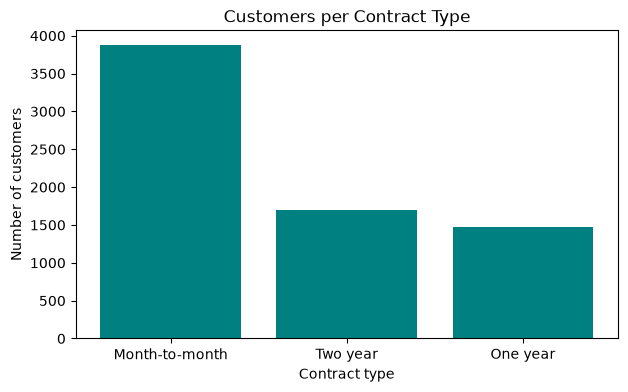

In [2]:
# Count customers by Contract type and draw a bar chart.
counts = df["Contract"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color="teal")
plt.title("Customers per Contract Type")
plt.xlabel("Contract type")
plt.ylabel("Number of customers")
plt.show()

Month-to-month contracts are the most common contract type in the dataset.

## Step 2: Histogram of Tenure

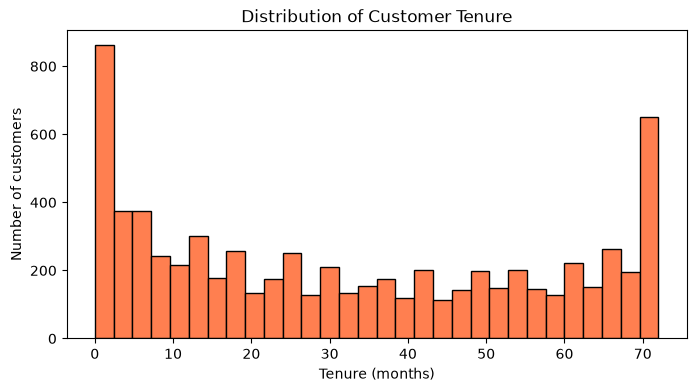

In [3]:
# Plot tenure values with 30 bins to see how long customers have stayed.
plt.figure(figsize=(8, 4))
plt.hist(df["tenure"], bins=30, color="coral", edgecolor="black")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of customers")
plt.show()

The histogram has many very new customers and many long-term customers, which makes tenure useful for churn analysis.

## Step 3: Scatter Plot - MonthlyCharges vs TotalCharges

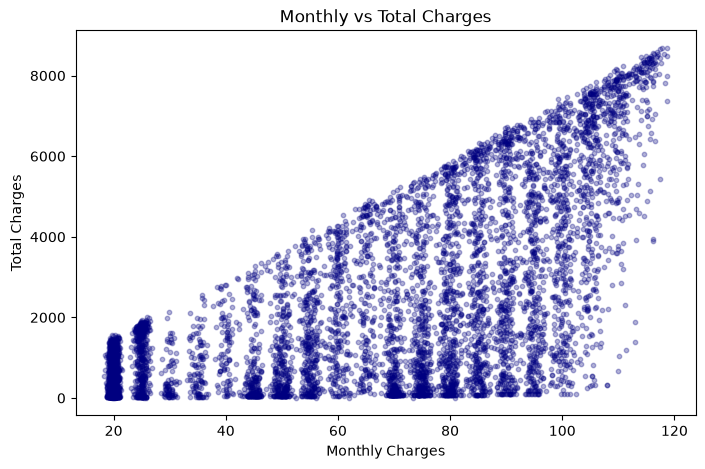

In [4]:
# Compare MonthlyCharges and TotalCharges with a scatter plot.
plt.figure(figsize=(8, 5))
plt.scatter(df["MonthlyCharges"], df["TotalCharges"], alpha=0.3, s=10, color="navy")
plt.title("Monthly vs Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

The scatter plot shows a positive relationship because customers with higher monthly bills usually build higher total charges over time.

## Step 4: Box Plot - MonthlyCharges by Contract

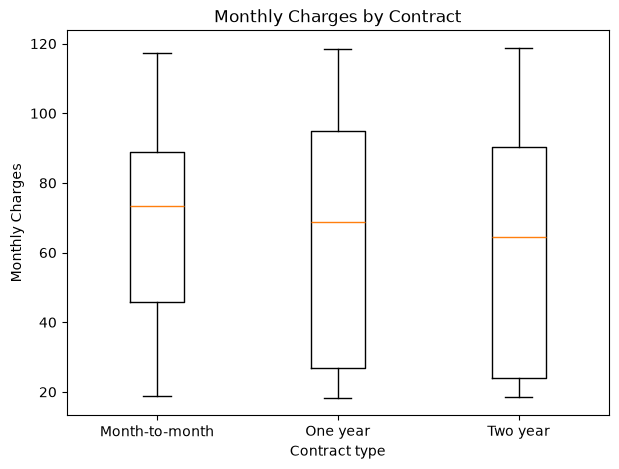

In [5]:
# Compare MonthlyCharges across the three Contract groups.
contract_order = ["Month-to-month", "One year", "Two year"]
groups = [df[df["Contract"] == contract]["MonthlyCharges"] for contract in contract_order]

plt.figure(figsize=(7, 5))
plt.boxplot(groups, tick_labels=contract_order)
plt.title("Monthly Charges by Contract")
plt.xlabel("Contract type")
plt.ylabel("Monthly Charges")
plt.show()

The box plot makes it easy to compare the middle range and spread of monthly charges for each contract type.

## Step 5: Subplots - Three Charts Side by Side

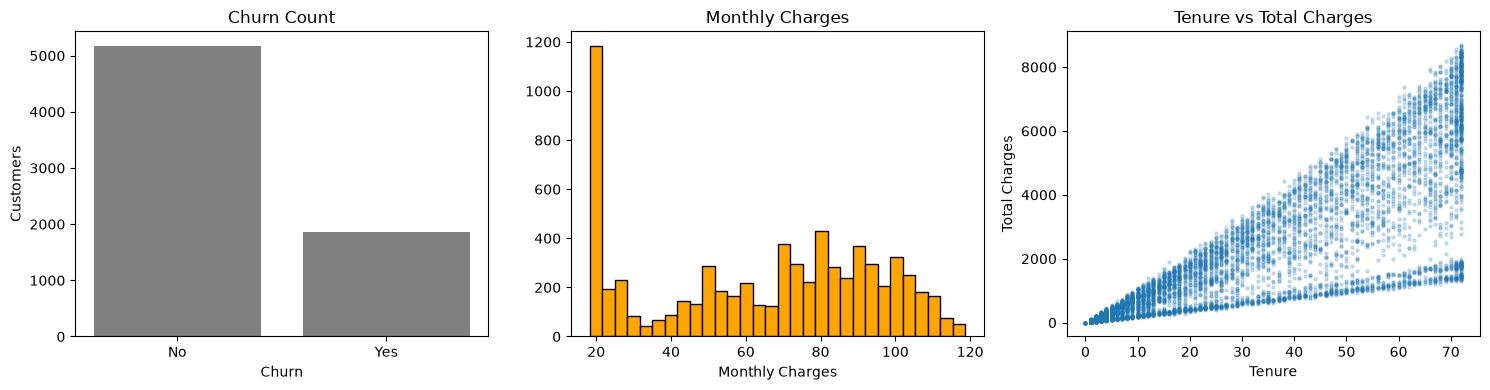

In [6]:
# Build a 1x3 figure with churn count, monthly charge histogram, and tenure vs total charges.
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

churn_counts = df["Churn"].value_counts()
ax[0].bar(churn_counts.index, churn_counts.values, color="gray")
ax[0].set_title("Churn Count")
ax[0].set_xlabel("Churn")
ax[0].set_ylabel("Customers")

ax[1].hist(df["MonthlyCharges"], bins=30, color="orange", edgecolor="black")
ax[1].set_title("Monthly Charges")
ax[1].set_xlabel("Monthly Charges")

ax[2].scatter(df["tenure"], df["TotalCharges"], alpha=0.2, s=5)
ax[2].set_title("Tenure vs Total Charges")
ax[2].set_xlabel("Tenure")
ax[2].set_ylabel("Total Charges")

plt.tight_layout()
plt.show()

## Final Note

All requested chart types are rendered with titles and axis labels. Each code cell includes a short comment explaining what the code does.